In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
%pwd

'/home/user8/dl-gen-lyrics/sandbox'

In [3]:
import sys
print(sys.version)

3.14.4 (main, Apr 14 2026, 14:26:14) [Clang 22.1.3 ]


In [4]:
import os, re, sys, traceback, csv, random

import numpy as np
import pandas as pd
import sentencepiece as spm
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'/home/user8/dl-gen-lyrics/sandbox'

In [5]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [6]:
import generator_core as core
from aspect_teal import Teal
import aspect_teal
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V

In [7]:
from dl_trainer import Trainer

In [8]:
batch_count = 103
genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
print(genres)
print(batch_count)

{'country', 'rock', 'rap', 'rb', 'misc', 'pop'}
103


In [9]:
total_subset_size = 100000
total_group_size = total_subset_size // len(genres) + 1
max_songs_per_artist = 50

In [10]:
ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
display(ds_subset.head())

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [11]:
teal = Teal(ds_subset)

Loaded Cache for Teal._prepare_ds_data.cached
Loaded Cache for Teal._get_custom_tokens.cached
Loaded Cache for Teal._get_genre_dict.cached
Loaded Cache for Teal._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp/lyrics_sp.model
Loaded Cache for Teal._prepare_embedder.cached
Loaded Cache for Teal._prepare_language_model.cached


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

cuda


In [13]:
word2vec = teal.embedder
word2vec

Word2Vec_SkipGram(
  (embeddings): Embedding(16000, 512)
  (linear): Linear(in_features=512, out_features=16000, bias=True)
)

In [14]:
word2vec.trainer.checkpoint_frequency_batch = 10
word2vec.trainer.device = 'cuda'
word2vec.trainer.learning_rate(0.001)

In [15]:
# word2vec.trainer.train()

In [16]:
try:
    flight = 'Teal._prepare_embedder.cached'
    for file in ['bone', 'pkl']:
        file = os.path.join('temp', f'{flight}.{file}')
        if os.path.exists(file): os.remove(file)
    core.key_cached('cached', lambda: word2vec, group='Teal._prepare_embedder')
    print("Done")
except:
    traceback.print_exc()

Done


In [17]:
try:
    train_language_model = True

    if train_language_model:
        teal.language_model = teal._prepare_language_model()

    print(teal.language_model)
except:
    traceback.print_exc()

Loaded Cache for Teal._prepare_language_model.cached
TransformerModel(
  (embed): Embedding(16000, 512, padding_idx=0)
  (pe): SinusoidalPE()
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (dropout): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): GQAAttention(
        (q_proj): Linear(in_features=512, out_features=512, bias=True)
        (k_proj): Linear(in_features=512, out_features=256, bias=True)
        (v_proj): Linear(in_features=512, out_features=256, bias=True)
        (out_proj): Linear(in_features=512, out_features=512, bias=True)
      )
      (ffn): GELUFFN(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
    )
  )
  (norm): LayerNorm()
  (head): Linear(in_features=512, out_features=16000, bias=True)
)


In [18]:
torch.cuda.empty_cache()

In [19]:
trainer = teal.language_model.trainer

In [20]:
trainer.learning_rate(0.00005)
trainer.epochs = 1

In [21]:
trainer.train()
# CPU Time: 34 sit

Epoch:  0/ 1    Train Loss: 2.04    TTS: 1.13    ETA: 5660.74
Epoch:  0/ 1    Train Loss: 2.39    TTS: 2.21    ETA: 3673.82
Epoch:  0/ 1    Train Loss: 2.32    TTS: 3.08    ETA: 3414.90
Epoch:  0/ 1    Train Loss: 2.45    TTS: 4.11    ETA: 3159.25
Epoch:  0/ 1    Train Loss: 2.21    TTS: 5.12    ETA: 3004.69
Epoch:  0/ 1    Train Loss: 2.38    TTS: 6.05    ETA: 2872.87
Epoch:  0/ 1    Train Loss: 1.85    TTS: 7.22    ETA: 2883.01
Epoch:  0/ 1    Train Loss: 2.46    TTS: 8.35    ETA: 2872.53
Epoch:  0/ 1    Train Loss: 2.10    TTS: 9.21    ETA: 2869.48
Epoch:  0/ 1    Train Loss: 2.61    TTS: 10.17    ETA: 2894.46
Epoch:  0/ 1    Train Loss: 2.20    TTS: 11.25    ETA: 2872.57
Epoch:  0/ 1    Train Loss: 2.32    TTS: 12.23    ETA: 2833.15
Epoch:  0/ 1    Train Loss: 3.06    TTS: 13.06    ETA: 2825.84
Epoch:  0/ 1    Train Loss: 2.37    TTS: 14.03    ETA: 2850.05
Epoch:  0/ 1    Train Loss: 2.79    TTS: 15.18    ETA: 2796.84
Epoch:  0/ 1    Train Loss: 2.65    TTS: 16.35    ETA: 2852.39
E

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.22 GiB. GPU 0 has a total capacity of 15.58 GiB of which 839.00 MiB is free. Including non-PyTorch memory, this process has 14.43 GiB memory in use. Of the allocated memory 11.98 GiB is allocated by PyTorch, and 2.30 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

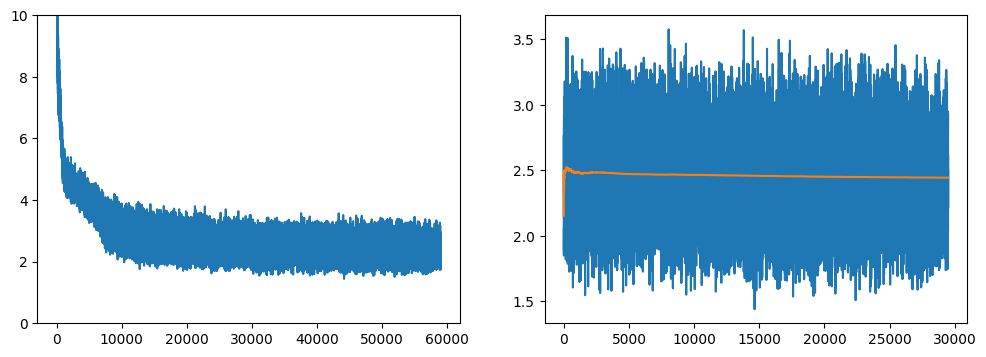

In [23]:
def running_average(nums):
    nums = np.asarray(nums, dtype=float)
    kernel = np.ones(len(nums))
    cumsum = np.convolve(nums, kernel, mode='full')[:len(nums)]
    counts = np.arange(1, len(nums) + 1)
    return cumsum / counts


loss = trainer.loss
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(loss['train.batch'])
axs[0].set_ylim(0,10)
axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
axs[1].plot(running_average(loss['train.batch'][int(0.5 * len(loss['train.batch'])):]))
plt.show()

In [24]:
try:
    flight = 'Teal._prepare_language_model.cached'
    for file in ['bone', 'pkl']:
        file = os.path.join('temp', f'{flight}.{file}')
        if os.path.exists(file): os.remove(file)
    core.key_cached('cached', lambda: teal.language_model, group='Teal._prepare_language_model')
    print("Saved")
except:
    traceback.print_exc()

Saved


In [25]:
for key in teal.language_model.trainer.timer.timers:
    print(key, trainer.timer.timers[key].average)

train 0.0
_train_step 0.0
train_dataloader 0.014799130776413616
batch 0.2844490249198243


In [37]:
try:
    print(teal.inference('rock', 
                         ['black', 'enter', 'spell', 'priests', 'dragon'], 
                         starting_words='<VERSE> i feel the fire', 
                         max_len=400, 
                         temperature=0.9,
                         top_k=50,
                         top_p=0.9, penalty=1.2).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

<SONG_START> <VERSE> i feel the fire in your veins
we fight and hide , formation of life is what you dreamt
with an ocean , burning in a red caves
burning all around my neck in black as they burn us down into outer space
because no one will hear me from this world that i must be set free from this dark road
yeah !
<CHORUS>
it's not always there to turn my eyes upon these walls
as we walk away from it , as we stand beside ourselves
a new day on our rights , through our rights
as we laughed into flames
just before the end
[ prehook ]
take off those who sit around and live their lives we know where they are coming from
this hell ?
this nightmare has been a mess now
when this heart feels cold ( so lonely )
<BRIDGE>
i cannot leave this world alone
yeah !
<CHORUS>
it's not always there to turn my eyes upon these walls
as we walk away from it , as we stand beside ourselves
a new day on our rights , through our rights
as we cry into flames
just before the end
<OUTRO>
the sun goes up and light
